# **Earthquake Analysis**
## *EDA Notebook* 


## Objectives

* Investigate the characteristics of our values to further inform the exploratory process

* Visualise how our target features interact and how to translate that as insights to behaviour

* Last minute adjustments before carving a feature matrix 

* Hypothesis testing

## Inputs

* The cleaned 'earthquake_1995-2023_cleaned.csv'

* Libraries containing the tools needed. Pandas, numpy, matplotlib , seaborn and sk-learn.

## Outputs

* Write here which files, code or artefacts you generate by the end of the notebook 

## Additional Comments

* If you have any additional comments that don't fit in the previous bullets, please state them here. 



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\NateM\\Desktop\\CI_DA\\Earthquake_Analysis\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\NateM\\Desktop\\CI_DA\\Earthquake_Analysis'

# Import block

These are the libraries required to process and inspect the data. 


In [4]:
# Librairies needed to perform analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

And load the .csv to a dataframe 

In [5]:
# .csv to dataframe
df_clean = pd.read_csv("Dataset/Cleaned/earthquake_1995-2023_cleaned.csv")

# View the dataframe
df_clean.head(10)

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,...,continent,country,mag_depth_interaction,depth_cat,is_off_shore,high,high_severity,year,month,hour
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,2023-08-16 12:47:00,7,4,green,0,657,us,114,...,off_shore,Vanuatu,1254.21,Intermediate,False,0,0,2023,8,12
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,2023-07-19 00:22:00,8,6,yellow,0,775,us,92,...,off_shore,off_shore,453.23,shallow,True,0,0,2023,7,0
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,2023-07-17 03:05:00,7,5,green,0,899,us,70,...,South America,Argentina,1131.05,Intermediate,False,1,1,2023,7,3
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,2023-07-16 06:48:00,6,6,green,1,860,us,173,...,off_shore,off_shore,234.51,shallow,True,0,0,2023,7,6
4,M 7.3 - Alaska Peninsula,7.3,2023-07-16 06:48:00,0,5,unassigned,1,820,at,79,...,off_shore,off_shore,153.30,shallow,True,0,0,2023,7,6
5,"M 6.6 - 277 km NNE of Codrington, Antigua and ...",6.6,2023-07-10 20:28:00,5,4,green,1,802,us,95,...,off_shore,off_shore,66.00,shallow,True,0,0,2023,7,20
6,M 6.9 - Tonga,6.9,2023-07-02 10:27:00,4,4,green,1,741,us,136,...,off_shore,off_shore,1580.10,Intermediate,True,0,0,2023,7,10
7,M 7.2 - south of the Fiji Islands,7.2,2023-06-15 18:06:00,8,6,green,1,804,us,85,...,off_shore,off_shore,1205.31,Intermediate,True,0,0,2023,6,18
8,M 6.6 - Panama-Colombia border region,6.6,2023-05-25 03:05:00,6,6,green,1,733,us,50,...,off_shore,Colombia,66.00,shallow,False,0,0,2023,5,3
9,M 7.1 - southeast of the Loyalty Islands,7.1,2023-05-20 01:51:00,3,4,green,1,777,us,98,...,off_shore,off_shore,255.47,shallow,True,0,0,2023,5,1


---

# Section 1 - Inital Exploration

We're going to to take a closer look at the distributions of our data.

First we'll inspect the continuous features, magnitude and depth.

In [14]:
stat_summ = df_clean[["magnitude", "depth"]].agg(
    ["mean", "median", "min", "max", "std"]
)
print("Summary:")
print(stat_summ.round(2))

Summary:
        magnitude   depth
mean         6.94   74.61
median       6.80   29.00
min          6.50    2.70
max          9.10  670.81
std          0.44  130.81


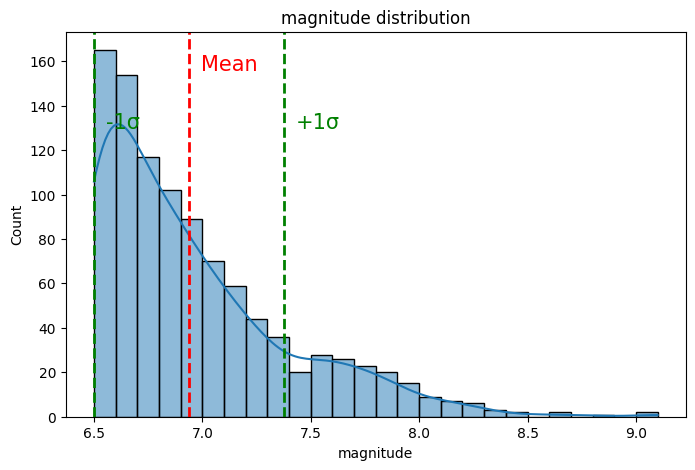

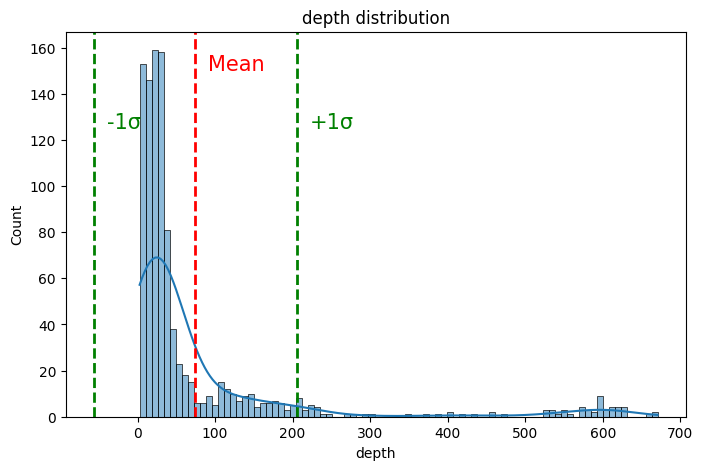

In [ ]:
# Storing columns into a variable 
continuous_columns = ["magnitude", "depth"]

# Visualise them
# Method and format taken from Code Institues 
# 'Descriptive Statistics Topic 3: Variability' lesson notebook
for column in continuous_columns:
  fig, axes = plt.subplots(figsize=(8,5))
  plt.title(f"{column} distribution")
  sns.histplot(
    data=df_clean,
    x=column,
    kde=True
  )

  plt.axvline(df_clean[column].mean(), color='r', linestyle='dashed', linewidth=2)
  plt.text(x=df_clean[column].mean() + df_clean[column].std()/8 , y=axes.get_ylim()[1] * 0.90, s='Mean', fontsize=15, c='r')

  plt.axvline(df_clean[column].mean() + df_clean[column].std(), color='g', linestyle='dashed', linewidth=2)
  plt.text(x=df_clean[column].mean() + df_clean[column].std() + df_clean[column].std()/8 , y=axes.get_ylim()[1] * 0.75, s='+1σ', fontsize=15, c='g')

  plt.axvline(df_clean[column].mean() - df_clean[column].std(), color='g', linestyle='dashed', linewidth=2)
  plt.text(x=df_clean[column].mean() - df_clean[column].std() + df_clean[column].std()/8 , y=axes.get_ylim()[1] * 0.75, s='-1σ', fontsize=15, c='g')

plt.show()

Magnitude has a mean of 6.9, a median of 6.8, and a standard deviation of 0.44. The small standard deviation shows that most recorded events stay close to the average. The distribution is positively skewed, demonstrating that higher-magnitude events 7.5 or greater are rare in comparison to the mean value. Because these right-tail extremes represent valid physical disasters rather than noise, we will keep them in our dataset.

Depth has a mean of 74.61 km, a median of 29.00 km, and a standard deviation of 130.02 km. The large standard deviation and high mean relative to the median reflect an extreme positive skew. This highlights the wide physical scale of earthquake origins, ranging from frequent shallow events in the surface crust of 0-70km, to rarer, deep-mantle subduction events reaching depths of 300km or more.


In [15]:
# # Plotting the distribution
# # Storing columns into a variable 
# continuous_columns = ["magnitude", "depth"]

# for column in continuous_columns:
#     plt.figure(figsize=(10,8)),
#     sns.histplot(
#         data=df_clean,
#         x=column,
#         bins=30,
#         kde=True
#         )
#     plt.xlabel(column)
#     plt.ylabel("Count")
#     plt.title(f"{column}")
#     plt.show()

---